In [1]:
from google.colab import drive
#Para conectar Google Drive con Colab
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# TensorFlow es la librería principal de Deep Learning.
# Permite crear, entrenar y evaluar redes neuronales.
import tensorflow as tf

# Keras viene integrado dentro de TensorFlow.
# Facilita la construcción de modelos.
from tensorflow.keras import layers
from tensorflow.keras import models

# Matplotlib sirve para generar gráficos.
# Más adelante la usaremos para accuracy y loss.
import matplotlib.pyplot as plt

# Numpy se utiliza para operaciones matemáticas y arreglos.
import numpy as np

In [ ]:
# RUTAS DEL DATASET

BASE_PATH = "/content/drive/MyDrive/COMPDES2026_Aves_CR/Dataset"

TRAIN_PATH = BASE_PATH + "/Training_set"


In [ ]:
# PARÁMETROS GENERALES

# Tamaño de imagen utilizado.
IMG_HEIGHT = 224
IMG_WIDTH = 224

# Cantidad de imágenes procesadas simultáneamente.
BATCH_SIZE = 32

# Semilla para reproducibilidad.
SEED = 42

In [ ]:
# CARGAR TRAINING SET

train_ds = tf.keras.utils.image_dataset_from_directory(

    TRAIN_PATH,

    image_size=(
        IMG_HEIGHT,
        IMG_WIDTH
    ),

    batch_size=BATCH_SIZE,

    seed=SEED,

    # Mantiene la relación de aspecto
    # agregando padding cuando sea necesario
    pad_to_aspect_ratio=True

)

Found 340 files belonging to 2 classes.


In [ ]:
# VERIFICAR CLASES

print(train_ds.class_names)

['Quiscalus_mexicanus_female', 'Turdus_grayi']


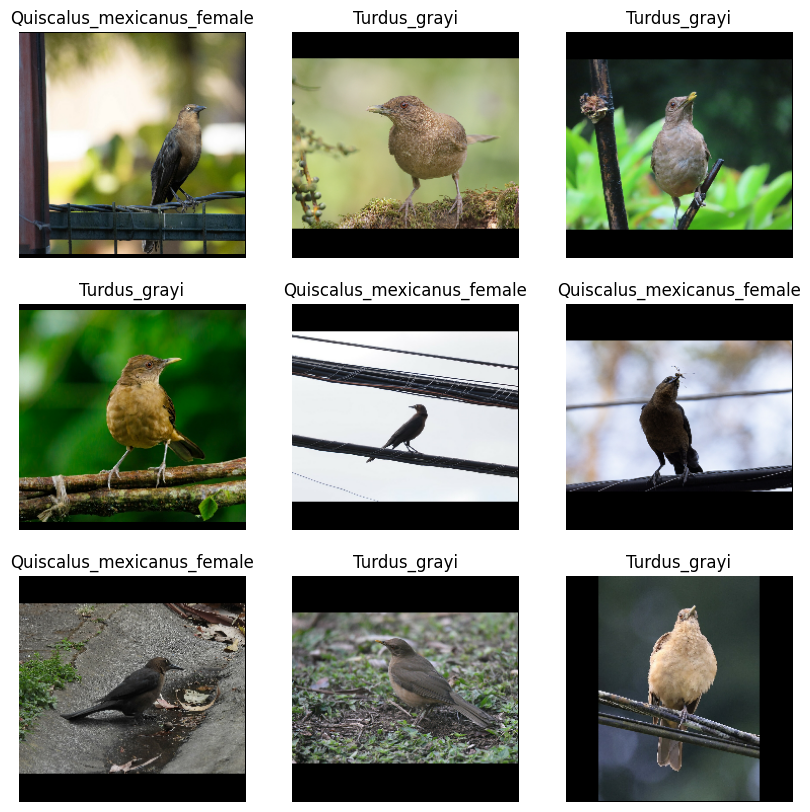

In [ ]:
# VISUALIZACIÓN DE IMÁGENES

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    cantidad = min(len(images), 9)

    for i in range(cantidad):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            train_ds.class_names[
                labels[i]
            ]
        )

        plt.axis("off")

plt.show()

In [ ]:
# AUMENTO DE DATOS

data_augmentation = tf.keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.2),

    layers.RandomZoom(0.2)

])

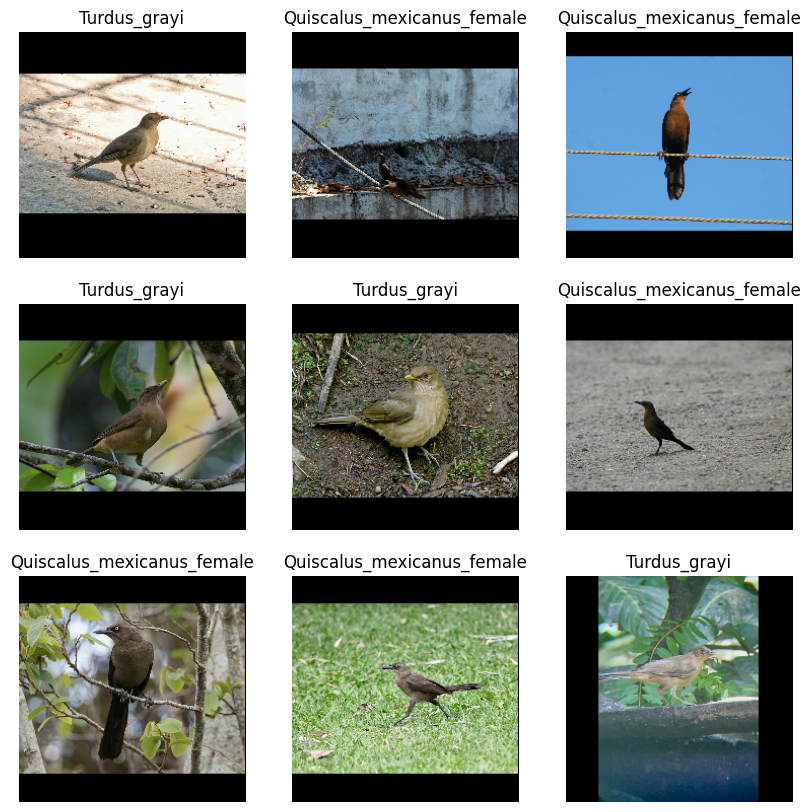

In [ ]:
# VISUALIZACIÓN DE IMÁGENES

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):

    cantidad = min(len(images), 9)

    for i in range(cantidad):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(
            images[i].numpy().astype("uint8")
        )

        plt.title(
            train_ds.class_names[
                labels[i]
            ]
        )

        plt.axis("off")

plt.show()

In [ ]:
# CNN BASELINE

model = models.Sequential([

    # Aumento de datos

    data_augmentation,

    # Normalización

    layers.Rescaling(1./255),

    # Bloque convolucional 1

    layers.Conv2D(
        32,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    # Bloque convolucional 2

    layers.Conv2D(
        64,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    # Bloque convolucional 3

    layers.Conv2D(
        128,
        (3,3),
        activation='relu'
    ),

    layers.MaxPooling2D(),

    # Conversión a vector

    layers.Flatten(),

    # Capa densa

    layers.Dense(
        128,
        activation='relu'
    ),

    # Regularización

    layers.Dropout(0.5),

    # Salida final

    layers.Dense(
        2,
        activation='softmax'
    )

])

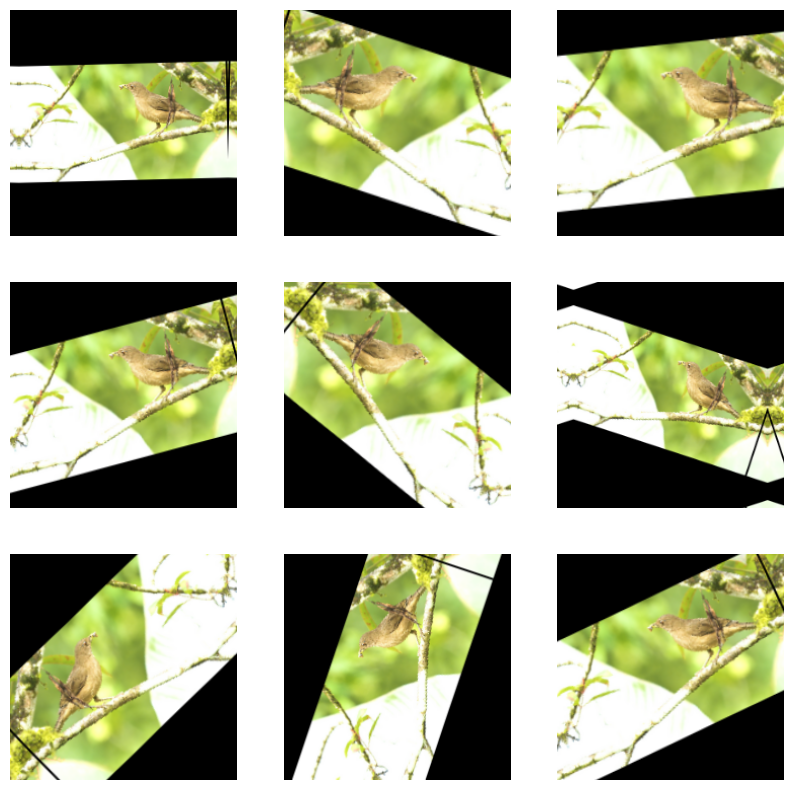

In [ ]:
for images, labels in train_ds.take(1):
    original = images[0]

plt.figure(figsize=(10,10))

for i in range(9):
    augmented = data_augmentation(
        tf.expand_dims(original,0),
        training=True
    )[0]

    ax = plt.subplot(3,3,i+1)
    plt.imshow(augmented.numpy().astype("uint8"))
    plt.axis("off")

In [ ]:
# RESUMEN DEL MODELO
model.build((None, 224, 224, 3))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,218 (42.61 MB)

 Trainable params: 11,169,218 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# COMPILAR MODELO

model.compile(

    optimizer='adam',

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

In [ ]:
# ENTRENAMIENTO INICIAL

history = model.fit(

    train_ds,

    epochs=20

)

Epoch 1/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 3s/step - accuracy: 0.5441 - loss: 1.1389
Epoch 2/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 942ms/step - accuracy: 0.5971 - loss: 0.6707
Epoch 3/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 619ms/step - accuracy: 0.6794 - loss: 0.6519
Epoch 4/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 926ms/step - accuracy: 0.6794 - loss: 0.6308
Epoch 5/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 736ms/step - accuracy: 0.6971 - loss: 0.6354
Epoch 6/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 688ms/step - accuracy: 0.7029 - loss: 0.6202
Epoch 7/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 804ms/step - accuracy: 0.6706 - loss: 0.6129
Epoch 8/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 624ms/step - accuracy: 0.7029 - loss: 0.6003
Epoch 9/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 655ms/step - accuracy: 0.6618 - loss: 0.6152
Epoch 10/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 924ms/step - accuracy: 0.7088 - loss: 0.5932
Epoch 11/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 8s 629ms/step - accuracy: 0.7382 - loss: 0.5493
Epoch 12/20
11/11 ━━━━━━━━━━━━━━━━━━━━ 11s 669ms/

In [ ]:
model.summary()

In [ ]:
plt.plot(history.history['accuracy'])
plt.show()

In [ ]:
plt.plot(history.history['loss'])
plt.show()

In [ ]:
#Guarda el modelo
model.save(
"/content/drive/MyDrive/COMPDES2026_Aves_CR/Resultados/cnn_baseline_avesCR.keras"
)

In [ ]:
#Cargar el modelo guardado

from tensorflow.keras.models import load_model

model = load_model(
    "/content/drive/MyDrive/COMPDES2026_Aves_CR/Resultados/cnn_baseline_avesCR.keras"
)

In [ ]:
#Crear Validation Dataset

import tensorflow as tf

VALIDATION_PATH = "/content/drive/MyDrive/COMPDES2026_Aves_CR/Dataset/Validation_set"

validation_ds = tf.keras.utils.image_dataset_from_directory(

    VALIDATION_PATH,

    image_size=(224,224),

    batch_size=32,

    shuffle=False,

    pad_to_aspect_ratio=True
)

In [ ]:
#Evaluación sobre Validation

validation_loss, validation_accuracy = model.evaluate(
    validation_ds
)

In [ ]:
#Crear Testing Dataset (Regular Photos)

TESTING_REGULAR_PATH = "/content/drive/MyDrive/COMPDES2026_Aves_CR/Dataset/Testing_set/Regular_photos"

test_regular_ds = tf.keras.utils.image_dataset_from_directory(

    TESTING_REGULAR_PATH,

    image_size=(224,224),

    batch_size=32,

    shuffle=False,

    pad_to_aspect_ratio=True
)

In [ ]:
#Evaluación sobre Testing Dataset (Regular Photos)

test_loss, test_accuracy = model.evaluate(
    test_regular_ds
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Valores reales
y_true = np.concatenate(
    [y.numpy() for x, y in test_regular_ds]
)

# Predicciones
predictions = model.predict(test_regular_ds)
y_pred = np.argmax(predictions, axis=1)

# Matriz
cm = confusion_matrix(y_true, y_pred)

# Nombres científicos completos
labels = [
    "Quiscalus mexicanus\n(hembra)",
    "Turdus grayi"
]

# Figura más grande
fig, ax = plt.subplots(figsize=(7,6))

# Escala suave para publicación
im = ax.imshow(
    cm,
    cmap="Blues"
)

# Barra lateral
cbar = plt.colorbar(im)
cbar.set_label("Cantidad de imágenes")

# Etiquetas
ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

ax.set_xlabel(
    "Clase predicha",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Clase real",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Matriz de confusión - CNN Baseline",
    fontsize=13,
    fontweight="bold"
)

# Mostrar valores dentro de cada celda
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        valor = cm[i, j]

        ax.text(
            j,
            i,
            str(valor),
            ha="center",
            va="center",
            fontsize=14,
            fontweight="bold",
            color="black"
        )

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/COMPDES2026_Aves_CR/Resultados/Matriz_Confusion_CNN_Baseline.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_true,
        y_pred,
        target_names=test_regular_ds.class_names
    )
)

In [ ]:
#Experimento Flying Photos

FLYING_PATH = "/content/drive/MyDrive/COMPDES2026_Aves_CR/Dataset/Testing_set/Flying_photos"

flying_ds = tf.keras.utils.image_dataset_from_directory(

    FLYING_PATH,

    image_size=(224,224),

    batch_size=32,

    shuffle=False,

    pad_to_aspect_ratio=True
)

In [ ]:
flying_loss, flying_accuracy = model.evaluate(
    flying_ds
)

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Etiquetas reales
y_true_flying = np.concatenate(
    [y.numpy() for x, y in flying_ds]
)

# Predicciones
predictions_flying = model.predict(
    flying_ds
)

y_pred_flying = np.argmax(
    predictions_flying,
    axis=1
)

cm_flying = confusion_matrix(
    y_true_flying,
    y_pred_flying
)

print(cm_flying)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = [
    "Quiscalus mexicanus\n(hembra)",
    "Turdus grayi"
]

# Normalización por fila
cm_percent = (
    cm_flying.astype("float")
    /
    cm_flying.sum(axis=1)[:, np.newaxis]
) * 100

fig, ax = plt.subplots(figsize=(7,6))

im = ax.imshow(
    cm_percent,
    cmap="Oranges",
    vmin=0,
    vmax=100
)

cbar = plt.colorbar(im)
cbar.set_label(
    "Porcentaje (%)",
    fontsize=11
)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))

ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)

ax.set_xlabel(
    "Clase predicha",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Clase real",
    fontsize=12,
    fontweight="bold"
)

ax.set_title(
    "Matriz de confusión - Fotografías en vuelo",
    fontsize=13,
    fontweight="bold"
)

# Mostrar cantidad y porcentaje
for i in range(cm_flying.shape[0]):
    for j in range(cm_flying.shape[1]):

        cantidad = cm_flying[i,j]

        porcentaje = cm_percent[i,j]

        texto = (
            f"{cantidad}\n"
            f"({porcentaje:.1f}%)"
        )

        ax.text(
            j,
            i,
            texto,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color="black"
        )

plt.tight_layout()

plt.savefig(
    "/content/drive/MyDrive/COMPDES2026_Aves_CR/Resultados/Matriz_Confusion_Flying_Photos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()